In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

In [35]:
result_files = ["../results/iprover_noschedule.csv", "../results/myprover_defaultConfig.csv"]
algorithms = ["iProver", "My Prover"]

algorithms_to_results = {alg: pd.read_csv(file) for alg, file in zip(algorithms, result_files)}

In [36]:
frames = []
for a in algorithms:

    df = algorithms_to_results[a]

    timing = df["time"]

    ## remove problems that could not be solved in time
    timing = timing[timing>=0]
    timing = timing[timing!=None]

    ## get times in ascending order 
    timing = sorted(timing)

    ## dataframe to hold algorithm times
    t = pd.DataFrame({'time' : timing })

    # record our position in the column as the number
    # of instances solved in up to the time in that row
    t['n_solved'] = list(range(1,1+len(t)))

    # label with the algorithm we're recording
    t['Prover'] = a

    # keep this frame to collate at the end
    frames.append(t)


data = pd.concat(frames, ignore_index=True)
data.head()

,time,n_solved,Prover
0,0.016755,1,iProver
1,0.017942,2,iProver
2,0.018935,3,iProver
3,0.018939,4,iProver
4,0.019317,5,iProver


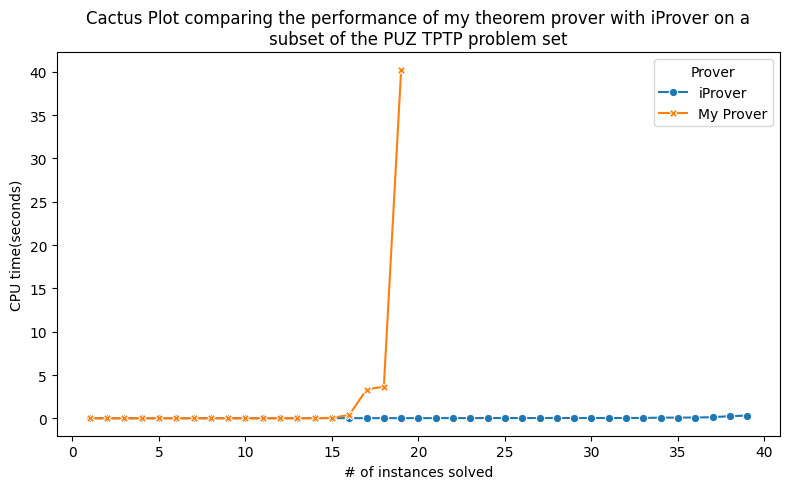

In [37]:
title = "Cactus Plot comparing the performance of my theorem prover with iProver on a subset of the PUZ TPTP problem set"
wrapped_title = "\n".join(textwrap.wrap(title, width=80))

fig,ax = plt.subplots(figsize=(8,5))
sns.lineplot(ax=ax,data=data,y='time',x='n_solved',
             hue='Prover',style='Prover',
             markers=True, dashes=False)

ax.set(title = wrapped_title, ylabel="CPU time(seconds)", xlabel="# of instances solved")
fig.tight_layout()